# Exercises in statistics

## Exercise 1

In this exercise we will use the penguins dataset (can be imported using the code `penguins_data = sns.load_dataset("penguins")`)

Please answer the following questions:
1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?
2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?
3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.
4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

In [1]:
#01


import seaborn as sns

penguins_data = sns.load_dataset("penguins")

species_count = penguins_data['species'].value_counts()
print("Number of penguins by species:")
print(species_count)

Number of penguins by species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [2]:
#02


from scipy import stats

def test_normality(data, alpha=0.05):
    p_value = stats.shapiro(data).pvalue
    return p_value > alpha

for species in penguins_data['species'].dropna().unique():
    body_mass = penguins_data[penguins_data['species'] == species]['body_mass_g'].dropna()
    is_normal = test_normality(body_mass)
    print(f"Is body mass for {species} normally distributed? {'Yes' if is_normal else 'No'}")

Is body mass for Adelie normally distributed? No
Is body mass for Chinstrap normally distributed? Yes
Is body mass for Gentoo normally distributed? Yes


In [3]:
#03


adelie_mass = penguins_data[penguins_data['species'] == 'Adelie']['body_mass_g'].dropna()
chinstrap_mass = penguins_data[penguins_data['species'] == 'Chinstrap']['body_mass_g'].dropna()

from scipy import stats

if test_normality(adelie_mass) and test_normality(chinstrap_mass):
    t_stat, p_value = stats.ttest_ind(adelie_mass, chinstrap_mass)
    test_type = "T-test"
else:
    t_stat, p_value = stats.mannwhitneyu(adelie_mass, chinstrap_mass)
    test_type = "Mann-Whitney U test"

print(f"Test: {test_type}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Conclusion: There is a significant difference in body mass between Adelie and Chinstrap penguins.")
else:
    print("Conclusion: There is no significant difference in body mass between Adelie and Chinstrap penguins.")

Test: Mann-Whitney U test
p-value: 0.4854772721011861
Conclusion: There is no significant difference in body mass between Adelie and Chinstrap penguins.


In [4]:
#04


gentoo_mass = penguins_data[penguins_data['species'] == 'Gentoo']['body_mass_g'].dropna()

if test_normality(chinstrap_mass) and test_normality(gentoo_mass):
    # If both are normal, use T-test
    t_stat, p_value = stats.ttest_ind(chinstrap_mass, gentoo_mass)
    test_type = "T-test"
else:
    t_stat, p_value = stats.mannwhitneyu(chinstrap_mass, gentoo_mass)
    test_type = "Mann-Whitney U test"

print(f"Test: {test_type}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Conclusion: There is a significant difference in body mass between Chinstrap and Gentoo penguins.")
else:
    print("Conclusion: There is no significant difference in body mass between Chinstrap and Gentoo penguins.")

Test: T-test
p-value: 5.266192723792513e-46
Conclusion: There is a significant difference in body mass between Chinstrap and Gentoo penguins.


## Exercise 2

Load in the "fb_like_and_share.csv" data and answer the following questions:

1. Is there a difference in the distribution of likes for photos and videos? Justify your choice of test(s).
2. Is there a difference in the distribution of share counts for photos and videos? Justify your choice of test(s).
3. Perform an ANOVA test to test if there is a difference in means across type of posts for shares. Does it make sense to perform this ANOVA test?
4. Is there actually a statistical significant difference in the distribution of share counts for any two groups?

In [5]:
import pandas as pd
import seaborn as sns
from scipy import stats

## Exercise 3

Load in the data "energySoftware.csv" and answer the following questions:
1. Plot the distribution of CPU for each test type
2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 
3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?
4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).
5. Perform an ANOVA test to test if there is a difference in means across groups for time

In [10]:
import pandas as pd

energy = pd.read_csv("energySoftware.csv")

energy.columns = [col.strip().lower().replace(" ", "_") for col in energy.columns]

print(energy.columns)

Index(['test', 'pkg', 'cpu', 'nn', 'nn2', 'time'], dtype='str')


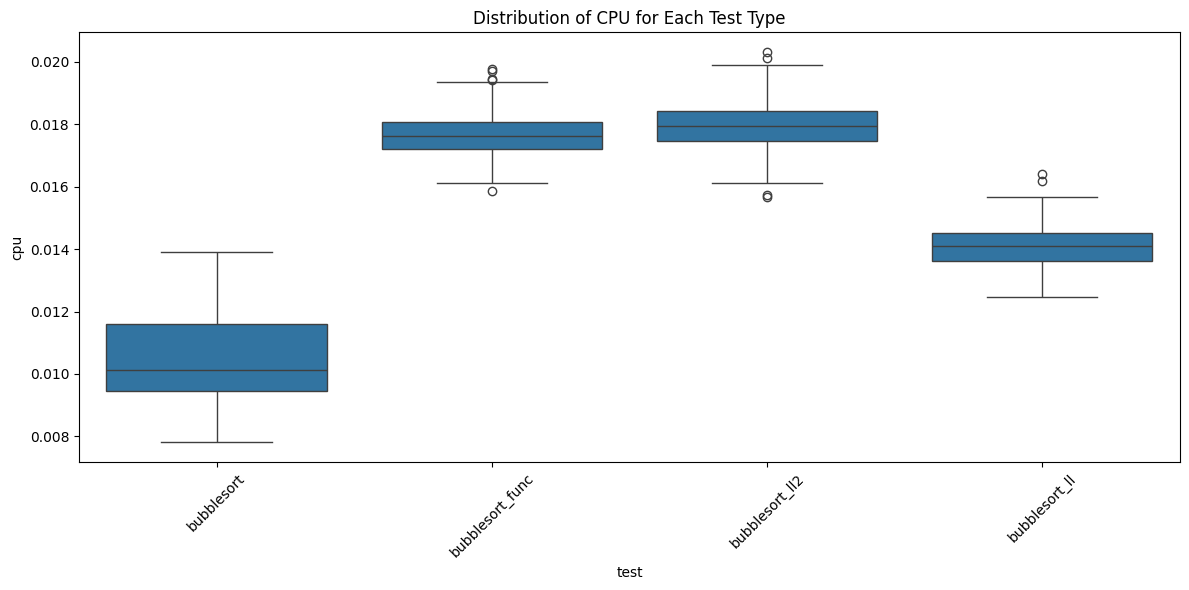

In [9]:
#01


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

energy = pd.read_csv("energySoftware.csv")

energy.columns = [col.strip().lower().replace(" ", "_") for col in energy.columns]

plt.figure(figsize=(12, 6))
sns.boxplot(data=energy, x='test', y='cpu') 
plt.xticks(rotation=45)
plt.title("Distribution of CPU for Each Test Type")
plt.tight_layout()
plt.show()

In [11]:
#02


bubblesort_cpu = energy[energy['test'] == "bubblesort"]['cpu'].dropna()
bubblesort_ll_cpu = energy[energy['test'] == "bubblesort_ll"]['cpu'].dropna()

def test_normality(data, alpha=0.05):
    p_value = stats.shapiro(data).pvalue
    return p_value > alpha

if test_normality(bubblesort_cpu) and test_normality(bubblesort_ll_cpu):
    t_stat, p_value = stats.ttest_ind(bubblesort_cpu, bubblesort_ll_cpu)
    test_type = "T-test"
else:
    t_stat, p_value = stats.mannwhitneyu(bubblesort_cpu, bubblesort_ll_cpu)
    test_type = "Mann-Whitney U test"

print(f"Test: {test_type}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Conclusion: There is a significant difference in CPU between bubblesort and bubblesort_ll.")
else:
    print("Conclusion: There is no significant difference in CPU between bubblesort and bubblesort_ll.")

Test: Mann-Whitney U test
p-value: 3.79156286604797e-117
Conclusion: There is a significant difference in CPU between bubblesort and bubblesort_ll.


In [12]:
#03

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

bubblesort_func_cpu = energy[energy['test'] == "bubblesort_func"]['cpu'].dropna()
bubblesort_ll2_cpu = energy[energy['test'] == "bubblesort_ll2"]['cpu'].dropna()

def test_normality(data, alpha=0.05):
    p_value = stats.shapiro(data).pvalue
    return p_value > alpha

def cohen_d(x, y):
    x = np.array(pd.Series(x).dropna())
    y = np.array(pd.Series(y).dropna())

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )

    if pooled_std == 0:
        return 0

    return (np.mean(x) - np.mean(y)) / pooled_std

if test_normality(bubblesort_func_cpu) and test_normality(bubblesort_ll2_cpu):
    t_stat, p_value = stats.ttest_ind(bubblesort_func_cpu, bubblesort_ll2_cpu)
    test_type = "T-test"
else:
    t_stat, p_value = stats.mannwhitneyu(bubblesort_func_cpu, bubblesort_ll2_cpu)
    test_type = "Mann-Whitney U test"

if test_type == "T-test":
    effect_size = cohen_d(bubblesort_func_cpu, bubblesort_ll2_cpu)
else:
    effect_size = None

print(f"Test: {test_type}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Conclusion: There is a significant difference in CPU between bubblesort_func and bubblesort_ll2.")
    if effect_size:
        print(f"Cohen's d (effect size): {effect_size}")
else:
    print("Conclusion: There is no significant difference in CPU between bubblesort_func and bubblesort_ll2.")

Test: T-test
p-value: 3.235572934893308e-06
Conclusion: There is a significant difference in CPU between bubblesort_func and bubblesort_ll2.
Cohen's d (effect size): -0.34974139331066756


In [13]:
#04


bubblesort_time = energy[energy['test'] == "bubblesort"]['time'].dropna()
bubblesort_ll_time = energy[energy['test'] == "bubblesort_ll"]['time'].dropna()

if test_normality(bubblesort_time) and test_normality(bubblesort_ll_time):
    t_stat, p_value = stats.ttest_ind(bubblesort_time, bubblesort_ll_time)
    test_type = "T-test"
else:
    t_stat, p_value = stats.mannwhitneyu(bubblesort_time, bubblesort_ll_time)
    test_type = "Mann-Whitney U test"

print(f"Test: {test_type}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Conclusion: There is a significant difference in time between bubblesort and bubblesort_ll.")
else:
    print("Conclusion: There is no significant difference in time between bubblesort and bubblesort_ll.")

Test: Mann-Whitney U test
p-value: 0.00035855213302219286
Conclusion: There is a significant difference in time between bubblesort and bubblesort_ll.


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np  

energy = pd.read_csv("energySoftware.csv")

energy.columns = [col.strip().lower().replace(" ", "_") for col in energy.columns]

def test_normality(data, alpha=0.05):
    p_value = stats.shapiro(data).pvalue
    is_normal = p_value > alpha
    return is_normal, p_value

def cohen_d(x, y):
    x = np.array(pd.Series(x).dropna())
    y = np.array(pd.Series(y).dropna())

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )

    if pooled_std == 0:
        return 0

    return (np.mean(x) - np.mean(y)) / pooled_std

def anova_with_checks(df, group_col, value_col, alpha=0.05):
    groups = []
    group_names = []

    for name, group in df.groupby(group_col):
        vals = group[value_col].dropna()
        if len(vals) > 0:
            groups.append(vals)
            group_names.append(name)

    print(f"\nANOVA for {value_col} across {group_col}")
    print(f"Null hypothesis (H0): All group means are equal.")
    print(f"Alternative hypothesis (H1): At least one group mean is different.")
    print(f"Significance level (alpha) = {alpha}\n")

    normality_ok = True
    for name, vals in zip(group_names, groups):
        is_normal, p_norm = test_normality(vals, alpha)
        print(f"Normality p-value for group '{name}': {p_norm}")
        if not is_normal:
            normality_ok = False

    if len(groups) >= 2:
        lev_stat, lev_p = stats.levene(*groups)
        print(f"Levene test p-value for equality of variances: {lev_p}")
        equal_var_ok = lev_p > alpha
    else:
        equal_var_ok = False

    print()
    if normality_ok and equal_var_ok:
        print("ANOVA assumptions look reasonably okay.")
    else:
        print("ANOVA assumptions are not fully satisfied, so interpret ANOVA with caution.")
        print("For distribution differences, non-parametric tests are often better.\n")

    f_stat, p_value = stats.f_oneway(*groups)
    print(f"ANOVA F-statistic = {f_stat}")
    print(f"ANOVA p-value = {p_value}")

    if p_value < alpha:
        print("Conclusion: Reject H0 -> at least one group mean is different.\n")
    else:
        print("Conclusion: Fail to reject H0 -> no significant difference in group means.\n")

anova_with_checks(energy, 'test', 'time')


ANOVA for time across test
Null hypothesis (H0): All group means are equal.
Alternative hypothesis (H1): At least one group mean is different.
Significance level (alpha) = 0.05

Normality p-value for group 'bubblesort': 3.5117387717841384e-13
Normality p-value for group 'bubblesort_func': 1.0072957249889574e-25
Normality p-value for group 'bubblesort_ll': 3.2014552851553314e-21
Normality p-value for group 'bubblesort_ll2': 3.593361229728597e-18
Levene test p-value for equality of variances: 2.2628163250307224e-130

ANOVA assumptions are not fully satisfied, so interpret ANOVA with caution.
For distribution differences, non-parametric tests are often better.

ANOVA F-statistic = 2556.3329354127823
ANOVA p-value = 0.0
Conclusion: Reject H0 -> at least one group mean is different.

